# Семинар №2. Численное интегрирование и дифференцирование
## Математическая подготовка к лабораторной работе №2

# Что такое шаг $h$?

В этом семинаре буква $h$ используется **в двух близких, но не одинаковых смыслах**.

## 1. В численном интегрировании

Если отрезок $[a,b]$ разделён на $n$ равных частей, то

$$
h=\frac{b-a}{n}.
$$

Здесь $h$ — это **ширина одного маленького подынтервала**, то есть расстояние между соседними узлами сетки.

Например, если

$$
[a,b]=[0,2],\qquad n=4,
$$

то

$$
h=\frac{2-0}{4}=0.5.
$$

Тогда узлы сетки:

$$
0,\ 0.5,\ 1,\ 1.5,\ 2.
$$

---

## 2. В численном дифференцировании

Здесь $h$ — это **маленькое смещение от точки**, в которой хочется найти производную.

Если производную ищут в точке $x_0=1$ и взяли $h=0.1$, то:

- для правой разности используются точки $1$ и $1.1$;
- для центральной разности — точки $0.9$ и $1.1$.

---

## Коротко

- в интегрировании $h$ — **шаг сетки**, то есть ширина одного кусочка отрезка;
- в дифференцировании $h$ — **насколько далеко отходим от точки $x_0$**.

Чем меньше $h$, тем подробнее рассматривается функция, но при слишком малом $h$ в численном дифференцировании начинает мешать ошибка округления.

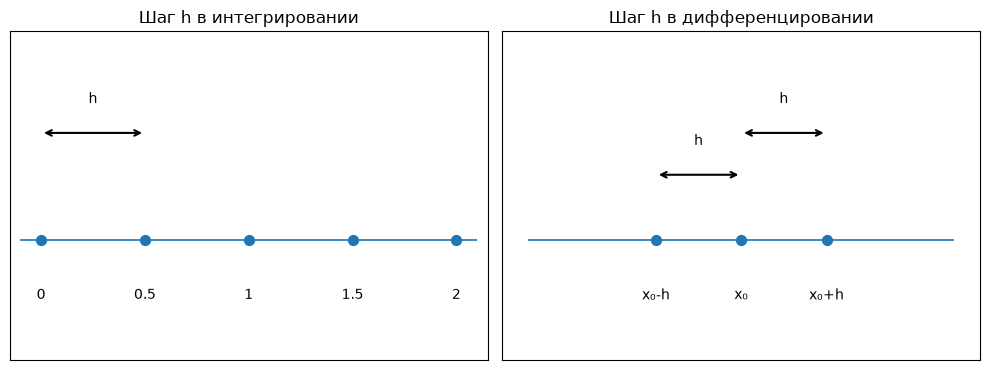

In [1]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

# График 1: шаг h в интегрировании.
ax = axes[0]
a, b, n = 0, 2, 4
x_nodes = np.linspace(a, b, n + 1)

ax.hlines(0, a - 0.1, b + 0.1, linewidth=1.2)
ax.scatter(x_nodes, np.zeros_like(x_nodes), s=50, zorder=3)

for x in x_nodes:
    ax.text(x, -0.08, f"{x:g}", ha="center", va="top")

ax.annotate("", xy=(x_nodes[0], 0.18), xytext=(x_nodes[1], 0.18),
            arrowprops=dict(arrowstyle="<->", lw=1.5))
ax.text((x_nodes[0] + x_nodes[1]) / 2, 0.23, "h", ha="center")
ax.set_title("Шаг h в интегрировании")
ax.set_ylim(-0.2, 0.35)
ax.set_xlim(a - 0.15, b + 0.15)
ax.set_yticks([])
ax.set_xticks([])
ax.grid(False)

# График 2: шаг h в дифференцировании.
ax = axes[1]
x0, h = 1.0, 0.1
points = np.array([x0 - h, x0, x0 + h])

ax.hlines(0, 0.75, 1.25, linewidth=1.2)
ax.scatter(points, np.zeros_like(points), s=50, zorder=3)

labels = ["x₀-h", "x₀", "x₀+h"]
for x, label in zip(points, labels):
    ax.text(x, -0.08, label, ha="center", va="top")

ax.annotate("", xy=(x0, 0.18), xytext=(x0 + h, 0.18),
            arrowprops=dict(arrowstyle="<->", lw=1.5))
ax.text(x0 + h/2, 0.23, "h", ha="center")

ax.annotate("", xy=(x0 - h, 0.11), xytext=(x0, 0.11),
            arrowprops=dict(arrowstyle="<->", lw=1.5))
ax.text(x0 - h/2, 0.16, "h", ha="center")

ax.set_title("Шаг h в дифференцировании")
ax.set_ylim(-0.2, 0.35)
ax.set_xlim(0.72, 1.28)
ax.set_yticks([])
ax.set_xticks([])
ax.grid(False)

plt.tight_layout()
plt.show()

# 1. Один пример на три квадратурные формулы

Рассмотрим

$$I=\int_0^2 x^4\,dx.$$

Сначала найдём **точное значение**, чтобы потом иметь возможность вычислять ошибку численного метода.

### Задание 1

1. Вычислите интеграл аналитически по формуле Ньютона–Лейбница.
2. Разделите отрезок $[0,2]$ на $n=4$ равные части.
3. Найдите шаг

$$h=\frac{b-a}{n}.$$

4. Выпишите узлы

$$x_i=a+ih,\qquad i=0,\ldots,n.$$

5. Вычислите $y_i=x_i^4$ во всех узлах.

Заполните таблицу:

| $i$ | $x_i$ | $y_i=x_i^4$ |
|---:|---:|---:|
| 0 |  |  |
| 1 |  |  |
| 2 |  |  |
| 3 |  |  |
| 4 |  |  |

<details>
<summary><b>Решение / комментарий преподавателю</b></summary>

$$I=\left.\frac{x^5}{5}\right|_0^2=\frac{32}{5}=6.4.$$

При $n=4$:

$$h=\frac{2-0}{4}=0.5.$$

Получаем:

| $i$ | $x_i$ | $x_i^4$ |
|---:|---:|---:|
| 0 | 0 | 0 |
| 1 | 0.5 | 0.0625 |
| 2 | 1.0 | 1 |
| 3 | 1.5 | 5.0625 |
| 4 | 2.0 | 16 |

Важно: для всех трёх методов используется **одна и та же разбивка** с $h=0.5$, но метод средних прямоугольников вычисляет функцию **в серединах** подынтервалов, а трапеции и Симпсон — в узлах сетки.

</details>

# 2. Метод средних прямоугольников

На каждом маленьком отрезке функция заменяется прямоугольником, высота которого берётся **в середине отрезка**.

Для составной формулы:

$$I_M=h\sum_{i=0}^{n-1}f\left(x_i+\frac{h}{2}\right).$$

### Задание 2

Для $n=4$:

1. Выпишите середины четырёх подынтервалов.
2. Вычислите $x^4$ в каждой середине.
3. Найдите приближение $I_M$.
4. Вычислите абсолютную ошибку

$$E_M=|I_M-I|.$$

### Вопрос

Получилось значение меньше или больше точного интеграла? Попробуйте объяснить это по форме графика $x^4$.

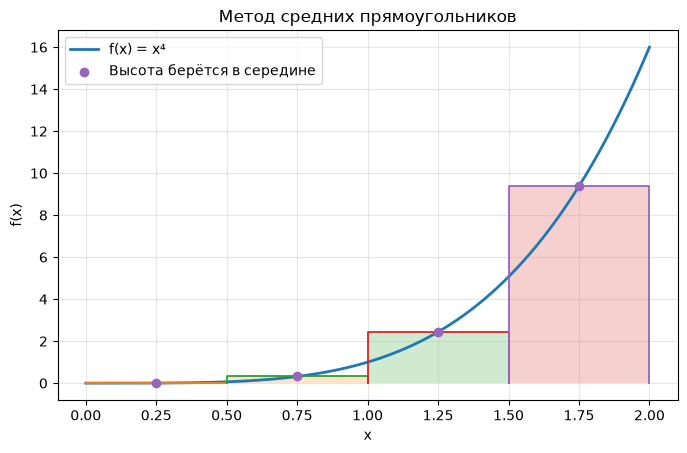

In [2]:
import numpy as np
import matplotlib.pyplot as plt

f = lambda x: x**4
a, b, n = 0.0, 2.0, 4
h = (b - a) / n
x_dense = np.linspace(a, b, 500)
edges = np.linspace(a, b, n + 1)
midpoints = edges[:-1] + h / 2

plt.figure(figsize=(8, 4.8))
plt.plot(x_dense, f(x_dense), linewidth=2, label="f(x) = x⁴")

for left, mid in zip(edges[:-1], midpoints):
    right = left + h
    height = f(mid)
    plt.fill_between([left, right], [0, 0], [height, height], alpha=0.22)
    plt.plot([left, left, right, right], [0, height, height, 0], linewidth=1.3)

plt.scatter(midpoints, f(midpoints), zorder=3, label="Высота берётся в середине")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Метод средних прямоугольников")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

На графике видно, что каждый маленький участок заменяется **прямоугольником постоянной высоты**.  
Высота выбирается по значению функции **в середине подынтервала**.

<details>
<summary><b>Решение / комментарий преподавателю</b></summary>

Середины:

$$0.25,\quad0.75,\quad1.25,\quad1.75.$$

Значения функции:

$$0.25^4=0.00390625,$$

$$0.75^4=0.31640625,$$

$$1.25^4=2.44140625,$$

$$1.75^4=9.37890625.$$

Их сумма равна $12.140625$, поэтому

$$I_M=0.5\cdot12.140625=6.0703125.$$

Ошибка:

$$E_M=|6.0703125-6.4|=0.3296875.$$

Получили **занижение**. На $[0,2]$ функция $x^4$ выпукла вверх: значение в середине каждого участка оказывается ниже среднего значения функции на этом участке.

</details>

# 3. Метод трапеций

Теперь на каждом подынтервале кривая заменяется **отрезком прямой**, соединяющим соседние узлы.

Составная формула:

$$I_T=
\frac{h}{2}
\left(
y_0+
2\sum_{i=1}^{n-1}y_i+
y_n
\right).$$

Крайние значения имеют вес $1$, внутренние — вес $2$.

### Задание 3

Используя уже найденные

$$y_0,\ldots,y_4,$$

вычислите:

1. внутреннюю сумму $y_1+y_2+y_3$;
2. значение $I_T$;
3. абсолютную ошибку $E_T$.

### Вопрос

Почему для функции, выпуклой вверх, трапеции дают значение **выше** точного интеграла?

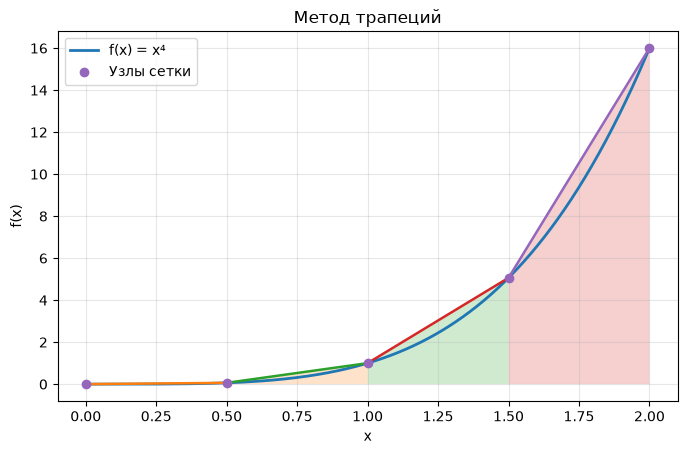

In [3]:
import numpy as np
import matplotlib.pyplot as plt

f = lambda x: x**4
a, b, n = 0.0, 2.0, 4
x_dense = np.linspace(a, b, 500)
x_nodes = np.linspace(a, b, n + 1)
y_nodes = f(x_nodes)

plt.figure(figsize=(8, 4.8))
plt.plot(x_dense, f(x_dense), linewidth=2, label="f(x) = x⁴")

for i in range(n):
    x_pair = [x_nodes[i], x_nodes[i + 1]]
    y_pair = [y_nodes[i], y_nodes[i + 1]]
    plt.fill_between(x_pair, [0, 0], y_pair, alpha=0.22)
    plt.plot(x_pair, y_pair, linewidth=1.8)

plt.scatter(x_nodes, y_nodes, zorder=3, label="Узлы сетки")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Метод трапеций")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Здесь каждый участок заменяется не прямоугольником, а **трапецией**.  
Верхняя сторона трапеции — это **отрезок**, соединяющий значения функции в соседних узлах.

<details>
<summary><b>Решение / комментарий преподавателю</b></summary>

Внутренняя сумма:

$$0.0625+1+5.0625=6.125.$$

Тогда

$$I_T=
\frac{0.5}{2}
\left(
0+2\cdot6.125+16
\right)
=0.25\cdot28.25
=7.0625.$$

Ошибка:

$$E_T=|7.0625-6.4|=0.6625.$$

Для выпуклой вверх функции хорда между двумя точками графика проходит выше самой кривой, поэтому площадь трапеций здесь переоценивает интеграл.

</details>

# 4. Метод Симпсона

Метод Симпсона использует уже не прямую, а **параболу**, проходящую через три соседних узла.

Для составной формулы при чётном $n$:

$$I_S=
\frac{h}{3}
\left[
y_0
+4(y_1+y_3+\ldots)
+2(y_2+y_4+\ldots)
+y_n
\right].$$

Весовая последовательность:

$$1,\ 4,\ 2,\ 4,\ 2,\ldots,\ 4,\ 1.$$

### Почему $n$ должно быть чётным?

Один фрагмент Симпсона использует **два подынтервала и три узла**. Поэтому весь отрезок должен разбиваться на пары подынтервалов.

### Задание 4

Для $n=4$ веса равны

$$1,\ 4,\ 2,\ 4,\ 1.$$

Вычислите $I_S$ и его абсолютную ошибку.

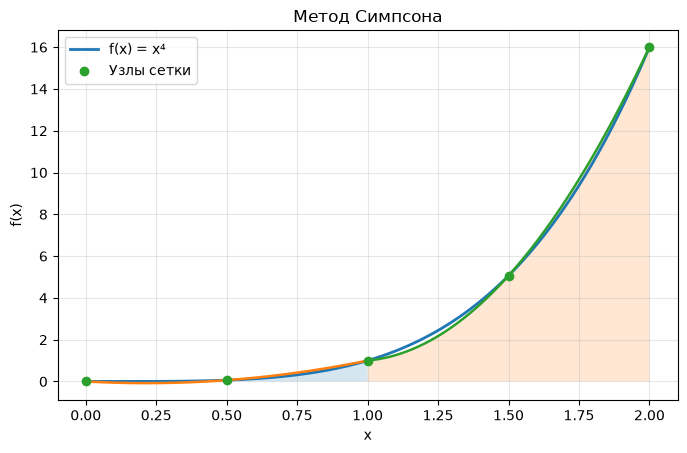

In [4]:
import numpy as np
import matplotlib.pyplot as plt

f = lambda x: x**4
a, b, n = 0.0, 2.0, 4
x_dense = np.linspace(a, b, 500)
x_nodes = np.linspace(a, b, n + 1)
y_nodes = f(x_nodes)

plt.figure(figsize=(8, 4.8))
plt.plot(x_dense, f(x_dense), linewidth=2, label="f(x) = x⁴")

for i in range(0, n, 2):
    xs = x_nodes[i:i+3]
    ys = y_nodes[i:i+3]
    coeff = np.polyfit(xs, ys, 2)
    x_panel = np.linspace(xs[0], xs[-1], 150)
    y_panel = np.polyval(coeff, x_panel)
    plt.plot(x_panel, y_panel, linewidth=1.8)
    plt.fill_between(x_panel, 0, y_panel, alpha=0.18)

plt.scatter(x_nodes, y_nodes, zorder=3, label="Узлы сетки")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Метод Симпсона")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Метод Симпсона использует не прямую, а **параболу**.  
Через каждые **три соседних узла** проводится квадратичная кривая, поэтому один фрагмент Симпсона охватывает **два подынтервала**.

<details>
<summary><b>Решение / комментарий преподавателю</b></summary>

$$I_S=
\frac{0.5}{3}
\left(
0+4\cdot0.0625+2\cdot1+4\cdot5.0625+16
\right).$$

Сумма в скобках:

$$0+0.25+2+20.25+16=38.5.$$

Поэтому

$$I_S=\frac{0.5}{3}\cdot38.5=6.416666\ldots$$

и

$$E_S\approx0.0166667.$$

На этой же сетке Симпсон получился значительно точнее двух предыдущих методов.

Это не случайность: составной метод Симпсона имеет порядок $O(h^4)$, тогда как средние прямоугольники и трапеции имеют порядок $O(h^2)$.

</details>

# 5. Сравнение трёх методов

Заполните итоговую таблицу по результатам предыдущих заданий.

| Метод | Приближение | Абсолютная ошибка |
|---|---:|---:|
| Средние прямоугольники |  |  |
| Трапеции |  |  |
| Симпсон |  |  |

### Вопросы для обсуждения

1. Какой метод оказался самым точным **при одной и той же величине шага $h$**?
2. Означает ли это, что один метод всегда будет давать лучший результат для любой функции?
3. Почему сравнивать методы только по значению интеграла недостаточно?
4. Что произойдёт, если уменьшать $h$?

<details>
<summary><b>Решение / комментарий преподавателю</b></summary>

| Метод | Приближение | Абсолютная ошибка |
|---|---:|---:|
| Средние прямоугольники | $6.0703125$ | $0.3296875$ |
| Трапеции | $7.0625$ | $0.6625$ |
| Симпсон | $6.4166667$ | $0.0166667$ |

На данном примере и данной сетке лучше всего сработал Симпсон.

Но корректный общий вывод не должен звучать как «Симпсон всегда лучше». Ошибка зависит от функции, гладкости, шага и реализации. В лабораторной важнее исследовать **закон уменьшения ошибки** при измельчении сетки.

</details>

# 6. Что такое порядок метода?

Часто ошибка численного метода приближённо ведёт себя как

$$E(h)\approx C h^p,$$

где:

- $h$ — шаг;
- $C$ — некоторая константа;
- $p$ — **порядок метода**.

Если шаг уменьшили в два раза:

$$h\rightarrow\frac{h}{2},$$

то

$$E\left(\frac{h}{2}\right)
\approx
\frac{E(h)}{2^p}.$$

Поэтому:

- при $p=1$ ошибка уменьшается примерно в $2$ раза;
- при $p=2$ — примерно в $4$ раза;
- при $p=4$ — примерно в $16$ раз.

Для нашего примера результаты при $n=4$ и $n=8$:

| Метод | $E_{n=4}$ | $E_{n=8}$ |
|---|---:|---:|
| Средние прямоугольники | 0.3296875 | 0.0831055 |
| Трапеции | 0.6625000 | 0.1664063 |
| Симпсон | 0.0166667 | 0.00104167 |

### Задание 5

Для каждого метода:

1. вычислите отношение

$$R=\frac{E_{n=4}}{E_{n=8}};$$

2. по величине $R$ определите порядок $p$;
3. при желании посчитайте точнее:

$$p\approx\log_2 R.$$

<details>
<summary><b>Решение / комментарий преподавателю</b></summary>

Для средних прямоугольников:

$$R\approx\frac{0.3296875}{0.0831055}\approx3.97,$$

поэтому $p\approx2$.

Для трапеций:

$$R\approx\frac{0.6625}{0.1664063}\approx3.98,$$

поэтому также $p\approx2$.

Для Симпсона:

$$R\approx\frac{0.0166667}{0.00104167}\approx16,$$

поэтому $p\approx4$.

Более точно:

$$p_M\approx1.99,\qquad
p_T\approx1.99,\qquad
p_S\approx4.00.$$

</details>

# 7. Причём здесь логарифм?

В лабораторной порядок оценивается по графику зависимости

$$\log(E)\quad\text{от}\quad\log(h).$$

Начинаем с

$$E(h)\approx Ch^p.$$

Берём логарифм:

$$\log E=\log C+p\log h.$$

Это обычное уравнение прямой

$$y=b+px.$$

если обозначить

$$y=\log E,\qquad x=\log h.$$

Следовательно, **наклон прямой на log-log графике и есть порядок $p$**.

### Задание 6

Ответьте без вычислений:

1. Какой наклон ожидается для средних прямоугольников?
2. Для трапеций?
3. Для Симпсона?
4. Если эксперимент дал наклон $3.96$, какой теоретический порядок, вероятнее всего, наблюдается?

<details>
<summary><b>Решение / комментарий преподавателю</b></summary>

Ожидаемые наклоны:

- средние прямоугольники: примерно $2$;
- трапеции: примерно $2$;
- Симпсон: примерно $4$.

Наклон $3.96$ практически соответствует четвёртому порядку. Экспериментальные значения не обязаны получаться идеально целыми из-за конечного диапазона шагов и округления.

</details>

Средние прямоугольники: p ≈ 1.997
Трапеции: p ≈ 1.999
Симпсон: p ≈ 4.000


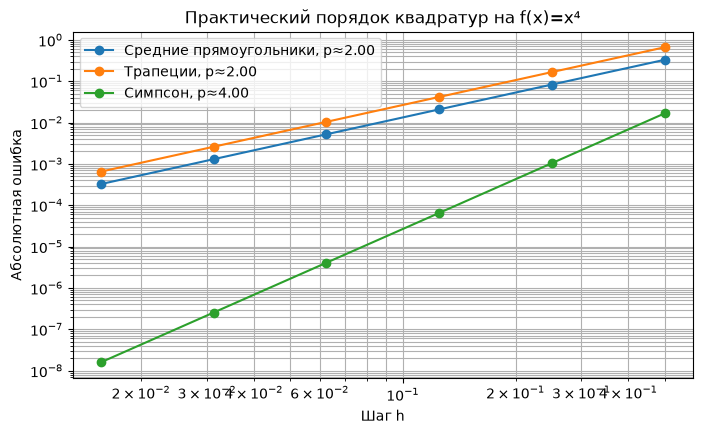

In [5]:
# @title Демонстрация: log-log график { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt

def midpoint_rule(f, a, b, n):
    h = (b - a) / n
    midpoints = a + h * (np.arange(n) + 0.5)
    return h * np.sum(f(midpoints))

def trapezoid_rule(f, a, b, n):
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    y = f(x)
    return (h / 2) * (y[0] + 2 * np.sum(y[1:-1]) + y[-1])

def simpson_rule(f, a, b, n):
    if n % 2 != 0:
        raise ValueError("Для метода Симпсона n должно быть чётным")
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    y = f(x)
    return (h / 3) * (
        y[0]
        + 4 * np.sum(y[1:-1:2])
        + 2 * np.sum(y[2:-1:2])
        + y[-1]
    )

f = lambda x: x**4
exact = 6.4
n_values = np.array([4, 8, 16, 32, 64, 128])

plt.figure(figsize=(8, 4.5))

for name, rule in [
    ("Средние прямоугольники", midpoint_rule),
    ("Трапеции", trapezoid_rule),
    ("Симпсон", simpson_rule),
]:
    h_values = 2 / n_values
    errors = np.array([abs(rule(f, 0, 2, int(n)) - exact) for n in n_values])
    p, _ = np.polyfit(np.log(h_values), np.log(errors), 1)

    print(f"{name}: p ≈ {p:.3f}")
    plt.loglog(h_values, errors, "o-", label=f"{name}, p≈{p:.2f}")

plt.xlabel("Шаг h")
plt.ylabel("Абсолютная ошибка")
plt.title("Практический порядок квадратур на f(x)=x⁴")
plt.grid(True, which="both")
plt.legend()
plt.show()

# 8. Численное дифференцирование

Теперь требуется приближённо найти производную в точке.

Правая разность:

$$D_+(h)=\frac{f(x+h)-f(x)}{h}.$$

Центральная разность:

$$D_0(h)=\frac{f(x+h)-f(x-h)}{2h}.$$

Возьмём простой пример:

$$f(x)=x^3,\qquad x_0=1.$$

Точная производная:

$$f'(x)=3x^2,\qquad f'(1)=3.$$

### Задание 7

При $h=0.1$ вручную вычислите:

1. $f(1)$;
2. $f(1.1)$;
3. $f(0.9)$;
4. правую разность;
5. центральную разность;
6. абсолютную ошибку каждого метода.

Какой метод оказался точнее?

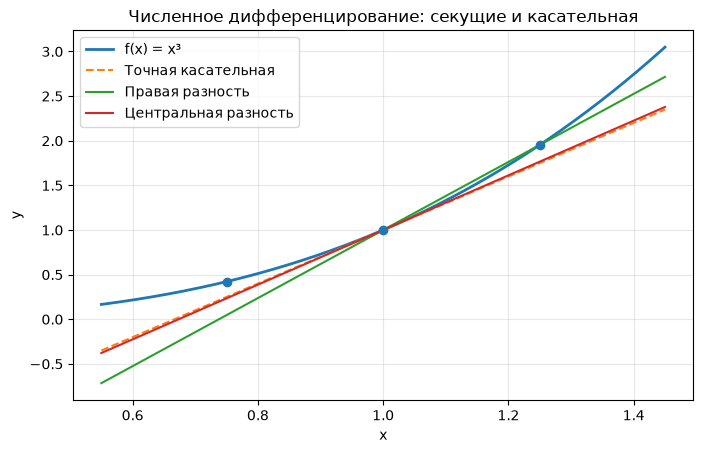

Точный наклон:        3.0000
Правая разность:      3.8125
Центральная разность: 3.0625


In [6]:
import numpy as np
import matplotlib.pyplot as plt

f = lambda x: x**3
df = lambda x: 3*x**2

x0 = 1.0
h = 0.25
x_dense = np.linspace(0.55, 1.45, 500)

# Точная касательная.
tangent = f(x0) + df(x0) * (x_dense - x0)

# Правая секущая.
slope_right = (f(x0 + h) - f(x0)) / h
right_line = f(x0) + slope_right * (x_dense - x0)

# Центральная секущая.
slope_central = (f(x0 + h) - f(x0 - h)) / (2*h)
central_line = f(x0) + slope_central * (x_dense - x0)

plt.figure(figsize=(8, 4.8))
plt.plot(x_dense, f(x_dense), linewidth=2, label="f(x) = x³")
plt.plot(x_dense, tangent, linestyle="--", label="Точная касательная")
plt.plot(x_dense, right_line, label="Правая разность")
plt.plot(x_dense, central_line, label="Центральная разность")
plt.scatter([x0-h, x0, x0+h], [f(x0-h), f(x0), f(x0+h)], zorder=4)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Численное дифференцирование: секущие и касательная")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"Точный наклон:        {df(x0):.4f}")
print(f"Правая разность:      {slope_right:.4f}")
print(f"Центральная разность: {slope_central:.4f}")

Производная в точке — это **наклон касательной**.  
Правая и центральная разности строят **секущие**, и их наклон используется как приближение производной.  
Чем лучше секущая «похожа» на касательную, тем точнее получается ответ.

<details>
<summary><b>Решение / комментарий преподавателю</b></summary>

$$f(1)=1,$$

$$f(1.1)=1.1^3=1.331,$$

$$f(0.9)=0.9^3=0.729.$$

Правая разность:

$$D_+(0.1)=\frac{1.331-1}{0.1}=3.31.$$

Ошибка:

$$|3.31-3|=0.31.$$

Центральная разность:

$$D_0(0.1)=\frac{1.331-0.729}{0.2}=3.01.$$

Ошибка:

$$|3.01-3|=0.01.$$

На этом примере центральная разность значительно точнее.

</details>

# 9. Почему у разностей разные порядки?

Для $f(x)=x^3$ это можно увидеть **без общего ряда Тейлора**.

### Задание 8. Правая разность

Подставьте $f(x)=x^3$ и $x=1$:

$$D_+(h)=\frac{(1+h)^3-1}{h}.$$

Раскройте куб и упростите выражение.

Затем найдите ошибку

$$D_+(h)-3.$$

Какова старшая степень $h$ в ошибке?

---

### Задание 9. Центральная разность

Аналогично:

$$D_0(h)=
\frac{(1+h)^3-(1-h)^3}{2h}.$$

Раскройте скобки и найдите ошибку относительно точного значения $3$.

Как зависит ошибка от $h$?

<details>
<summary><b>Решение / комментарий преподавателю</b></summary>

Для правой разности:

$$(1+h)^3=1+3h+3h^2+h^3.$$

Поэтому

$$D_+(h)=
\frac{3h+3h^2+h^3}{h}
=3+3h+h^2.$$

Ошибка:

$$D_+(h)-3=3h+h^2.$$

При малом $h$ главный член равен $3h$, поэтому ошибка имеет порядок

$$O(h).$$

Для центральной разности:

$$(1+h)^3=1+3h+3h^2+h^3,$$

$$(1-h)^3=1-3h+3h^2-h^3.$$

После вычитания:

$$(1+h)^3-(1-h)^3=6h+2h^3.$$

Тогда

$$D_0(h)=\frac{6h+2h^3}{2h}=3+h^2.$$

Ошибка равна

$$h^2,$$

то есть имеет порядок

$$O(h^2).$$

Причина более высокой точности центральной формулы — симметрия: часть членов ошибки взаимно сокращается.

</details>

# 10. Проверяем порядок ещё раз

Для той же функции $f(x)=x^3$ сравним два шага:

$$h_1=0.1,\qquad h_2=0.05.$$

Из предыдущего вывода:

$$E_{\text{right}}(h)=3h+h^2,$$

$$E_{\text{central}}(h)=h^2.$$

### Задание 10

1. Посчитайте обе ошибки при $h=0.1$.
2. Посчитайте обе ошибки при $h=0.05$.
3. Во сколько раз уменьшилась каждая ошибка при уменьшении шага вдвое?
4. Согласуется ли это с порядками $O(h)$ и $O(h^2)$?

<details>
<summary><b>Решение / комментарий преподавателю</b></summary>

Правая разность:

$$E_+(0.1)=3\cdot0.1+0.1^2=0.31,$$

$$E_+(0.05)=3\cdot0.05+0.05^2=0.1525.$$

Отношение:

$$\frac{0.31}{0.1525}\approx2.03.$$

Ошибка уменьшается примерно в два раза — первый порядок.

Центральная разность:

$$E_0(0.1)=0.01,$$

$$E_0(0.05)=0.0025.$$

Отношение:

$$\frac{0.01}{0.0025}=4.$$

Ошибка уменьшается ровно в четыре раза — второй порядок.

</details>

# 11. Почему нельзя просто взять очень маленький $h$?

До сих пор кажется логичным:

> чем меньше шаг, тем точнее ответ.

Для численного интегрирования это часто работает достаточно долго.

Но в конечных разностях возникает дополнительная проблема:

$$f(x+h)-f(x).$$

При очень маленьком $h$ числа $f(x+h)$ и $f(x)$ становятся почти одинаковыми.

Компьютер хранит вещественные числа с конечным количеством значащих цифр. При вычитании двух почти равных чисел часть значащих цифр теряется.

Это называется **катастрофическим сокращением**.

Поэтому есть два источника ошибки:

$$\text{общая ошибка}
\approx
\text{ошибка формулы}
+
\text{ошибка округления}.$$

При уменьшении $h$:

- ошибка формулы сначала уменьшается;
- ошибка округления в какой-то момент начинает расти.

Поэтому график ошибки от $h$ часто имеет минимум.

### Вопрос для обсуждения

Какой вывод правильнее?

**A.** Всегда брать максимально маленький $h$.

**B.** Существует разумный диапазон $h$, а слишком маленький шаг может ухудшить результат.

<details>
<summary><b>Решение / комментарий преподавателю</b></summary>

Правильный ответ — **B**.

Для конечных разностей предельно маленький шаг не гарантирует лучшую точность. Это как раз тот эффект, который требуется увидеть экспериментально в лабораторной работе.

</details>

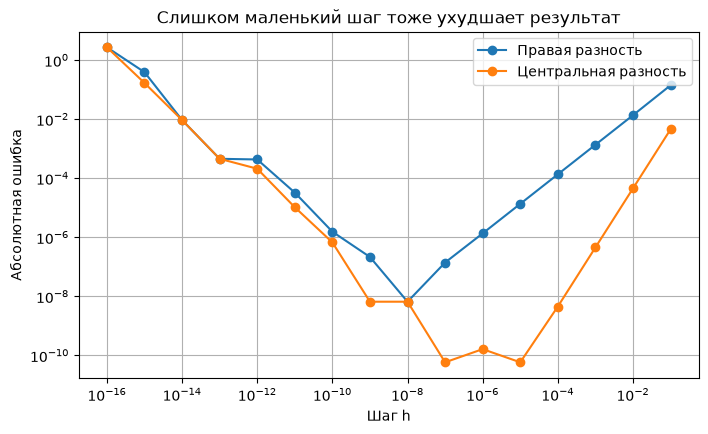

In [7]:
# @title Демонстрация преподавателя: ошибка округления { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt

f = np.exp
x0 = 1.0
exact = np.exp(1.0)

h_values = 10.0 ** (-np.arange(1, 17))

forward_errors = []
central_errors = []

for h in h_values:
    forward = (f(x0 + h) - f(x0)) / h
    central = (f(x0 + h) - f(x0 - h)) / (2 * h)

    forward_errors.append(abs(forward - exact))
    central_errors.append(abs(central - exact))

plt.figure(figsize=(8, 4.5))
plt.loglog(h_values, forward_errors, "o-", label="Правая разность")
plt.loglog(h_values, central_errors, "o-", label="Центральная разность")
plt.xlabel("Шаг h")
plt.ylabel("Абсолютная ошибка")
plt.title("Слишком маленький шаг тоже ухудшает результат")
plt.grid(True, which="both")
plt.legend()
plt.show()